# California Housing Price Prediction using Machine Learning

## Objective

The objective of this project is to predict California housing prices using multiple machine learning regression models and analyze their performance using evaluation metrics such as Mean Squared Error (MSE) and R² Score.

The project focuses on understanding model behavior, comparing regression algorithms, analyzing generalization performance, and studying the impact of preprocessing and outlier handling on machine learning models.

## Models Compared

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

## Evaluation Metrics Used

- Mean Squared Error (MSE)
- R² Score
- Training Score vs Testing Score Comparison

## Project Goals

- Build and train multiple regression models
- Compare model performance and prediction accuracy
- Analyze model generalization behavior
- Perform exploratory data analysis (EDA)
- Detect and handle outliers using the IQR method
- Understand how preprocessing affects machine learning performance

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Dataset Overview

The California Housing dataset contains housing-related information collected from districts across California. The dataset includes numerical features such as median income, house age, average rooms, average bedrooms, population, occupancy, latitude, and longitude.

The target variable represents the median house value for California districts.

In [4]:
dataset=fetch_california_housing()
X=dataset.data
y=dataset.target
df=pd.DataFrame(X,columns=dataset.feature_names)

In [5]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Initial Dataset Preview

The dataset preview helps understand the structure of the data, feature names, and sample observations before performing analysis and preprocessing.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


## Dataset Information

- The dataset contains 20,640 entries and 8 numerical feature columns.
- All columns are stored as floating-point numerical values.
- No missing values are present in the dataset.
- Since all features are numerical, the dataset is directly suitable for regression-based machine learning models.

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


## Statistical Observations

- Median income values vary significantly across districts.
- Population-related features contain large value ranges and possible extreme observations.
- Features such as `AveRooms`, `AveBedrms`, and `AveOccup` contain unusually large maximum values, indicating potential outliers.
- Latitude and Longitude values represent geographical spread across California regions.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand feature distributions, detect skewness, identify possible outliers, and analyze dataset characteristics before model training.

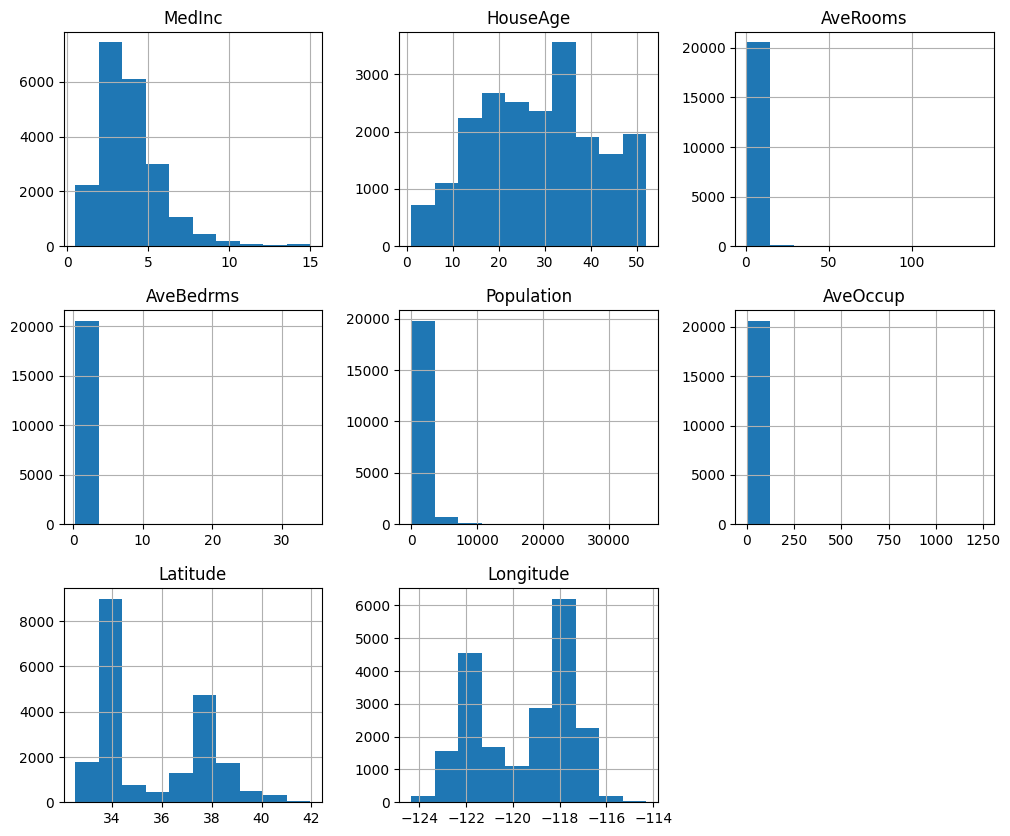

In [9]:
df.hist(figsize=(12,10))
plt.show()

## Histogram Observations

- `MedInc` shows a right-skewed distribution where most districts have moderate income values while fewer districts have very high income values.
- `AveRooms`, `AveBedrms`, and `AveOccup` contain highly skewed distributions with extreme observations.
- Population values also show large spread and variability across districts.
- Several features contain unusually large values that may influence regression model performance.
- Latitude and Longitude distributions reflect geographical clustering across California regions.

In [10]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


## Correlation Analysis

- `AveRooms` and `AveBedrms` show strong positive correlation, indicating that houses with more rooms generally contain more bedrooms.
- `Latitude` and `Longitude` show strong negative correlation because of geographical positioning patterns.
- Some features show weaker relationships, indicating varying predictive importance across variables.

# Data Preprocessing

The dataset was divided into training and testing sets to evaluate how well the models generalize to unseen data. Feature variables and target variables were separated before model training.

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Linear Regression

## Model Overview

Linear Regression is a regression algorithm that assumes a linear relationship between input features and the target variable. It is commonly used as a baseline model for regression problems.

In [13]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [14]:
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

0.5558915986952422
0.5757877060324524


In [19]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.6125511913966952
0.5757877060324524


## Initial Linear Regression Results

- Mean Squared Error (MSE): 0.5559
- R² Score: 0.5758
- Training Score: 0.6126
- Testing Score: 0.5758

## Initial Linear Regression Observations

- Linear Regression provided stable baseline performance on the dataset.
- Training and testing scores were relatively close, indicating reasonable generalization.
- The model may have been affected by skewed feature distributions and extreme values present in the dataset.

# Outlier Detection and Handling using IQR

## Objective

Outlier detection was performed using the Interquartile Range (IQR) method to analyze whether removing extreme values from highly skewed features improves Linear Regression performance.

The features selected for outlier handling were:
- `AveRooms`
- `AveBedrms`
- `AveOccup`

These features showed strong skewness and unusually large values during exploratory data analysis.

In [45]:
df['Target'] = dataset.target

q1=df['AveRooms'].quantile(0.25)
q3=df['AveRooms'].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr

q1_second=df['AveBedrms'].quantile(0.25)
q3_second=df['AveBedrms'].quantile(0.75)
iqr_second=q3_second-q1_second
lower_second=q1_second-1.5*iqr_second
upper_second=q3_second+1.5*iqr_second

q1_third=df['AveOccup'].quantile(0.25)
q3_third=df['AveOccup'].quantile(0.75)
iqr_third=q3_third-q1_third
lower_third=q1_third-1.5*iqr_third
upper_third=q3_third+1.5*iqr_third

df1=pd.DataFrame(df[(df['AveRooms']>=lower) & (df['AveRooms']<=upper) & (df['AveBedrms']>=lower_second) & (df['AveBedrms']<=upper_second) & (df['AveOccup']>=lower_third) & (df['AveOccup']<=upper_third)])
X1 = df1.drop('Target', axis=1)
y1 = df1['Target']

X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=42)
model3=LinearRegression()
model3.fit(X1_train,y1_train)
y1_pred=model3.predict(X1_test)
print(mean_squared_error(y1_test,y1_pred))
print(r2_score(y1_test,y1_pred))


0.4095283473313145
0.6844259113562827


## Linear Regression Results After Outlier Removal

- Mean Squared Error (MSE): 0.4095
- R² Score: 0.6844

In [47]:
print(model3.score(X1_train, y1_train))
print(model3.score(X1_test, y1_test))

0.6420531185306535
0.5415803660018913


## Observations After Outlier Handling

- Removing outliers from multiple skewed features significantly improved Linear Regression performance.
- Prediction error reduced substantially after preprocessing.
- The R² score increased considerably, indicating improved predictive capability.
- The experiment demonstrated that Linear Regression is sensitive to extreme values and benefits from selective preprocessing.

The outlier removal experiment was specifically performed to study the sensitivity of Linear Regression to extreme values.

# Population Outlier Experiment

An additional outlier removal experiment was performed on the `Population` feature to analyze whether removing extreme population values improves model performance.

In [46]:
q1=df['Population'].quantile(0.25)
q3=df['Population'].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr


df1=pd.DataFrame(df[(df['Population']>=lower) & (df['Population']<=upper)])
X1 = df1.drop('Target', axis=1)
y1 = df1['Target']

X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=42)
model3=LinearRegression()
model3.fit(X1_train,y1_train)
y1_pred=model3.predict(X1_test)
print(mean_squared_error(y1_test,y1_pred))
print(r2_score(y1_test,y1_pred))

0.603108170128948
0.5415803660018913


## Population Outlier Experiment Observations

- Removing Population outliers reduced model performance significantly.
- The decrease in R² score suggests that Population extremes contained meaningful predictive information.
- This experiment demonstrated that not all outliers should be removed.

# Decision Tree Regressor

## Model Overview

Decision Tree Regressor creates rule-based splits in the dataset to capture complex relationships between input features and target values.

In [15]:
model1=DecisionTreeRegressor()
model1.fit(X_train,y_train)
y1_pred=model1.predict(X_test)

In [16]:
print(mean_squared_error(y_test,y1_pred))
print(r2_score(y_test,y1_pred))

0.501574643879966
0.6172380896281079


In [20]:
print(model1.score(X_train, y_train))
print(model1.score(X_test, y_test))

1.0
0.6172380896281079


## Decision Tree Results

- Mean Squared Error (MSE): 0.5016
- R² Score: 0.6172
- Training Score: 1.0000
- Testing Score: 0.6172

## Decision Tree Observations

- Decision Tree achieved better predictive performance than the initial Linear Regression model.
- The model learned complex feature relationships effectively.
- The perfect training score indicates extremely strong fitting on training data.
- The large gap between training and testing performance suggests overfitting behavior.
- Although testing performance remained reasonably good, the model memorized training patterns too aggressively, reducing generalization capability compared to more balanced models.

# Random Forest Regressor

## Model Overview

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [17]:
model2=RandomForestRegressor()
model2.fit(X_train,y_train)
y2_pred=model2.predict(X_test)

In [18]:
print(mean_squared_error(y_test,y2_pred))
print(r2_score(y_test,y2_pred))

0.25590909660803374
0.8047105133913478


In [21]:
print(model2.score(X_train, y_train))
print(model2.score(X_test, y_test))

0.9734930195250848
0.8047105133913478


## Random Forest Results

- Mean Squared Error (MSE): 0.2559
- R² Score: 0.8047
- Training Score: 0.9735
- Testing Score: 0.8047

## Random Forest Observations

- Random Forest achieved the best predictive performance among all tested models.
- The ensemble approach improved generalization and reduced prediction error significantly.
- Training and testing scores remained relatively strong, indicating effective learning behavior.

# Model Comparison

| Model | MSE | R² Score | Train Score | Test Score |
|---|---|---|---|---|
| Initial Linear Regression | 0.5559 | 0.5758 | 0.6126 | 0.5758 |
| Linear Regression After Outlier Removal | 0.4095 | 0.6844 | 0.6421 | 0.6844 |
| Decision Tree Regressor | 0.5016 | 0.6172 | 1.0000 | 0.6172 |
| Random Forest Regressor | 0.2559 | 0.8047 | 0.9735 | 0.8047 |

## Model Comparison Insights

- Outlier handling significantly improved Linear Regression performance.
- The improved Linear Regression model outperformed Decision Tree Regressor after selective preprocessing and outlier removal.
- Decision Tree learned complex relationships effectively but showed overfitting behavior because of extremely high training accuracy.
- Random Forest achieved the best overall predictive performance and strongest generalization capability among all tested models.
- The project demonstrated that data preprocessing and feature quality can strongly influence machine learning model performance, even without changing the algorithm itself.

# Conclusion

This project explored multiple machine learning regression models for California housing price prediction using the California Housing dataset.

Exploratory Data Analysis helped identify skewed feature distributions and extreme observations within the dataset. Selective outlier removal using the IQR method significantly improved Linear Regression performance, demonstrating the importance of preprocessing in machine learning workflows.

Among all tested models, Random Forest Regressor achieved the best overall performance, while the improved Linear Regression model demonstrated how better data quality can substantially improve even simple algorithms.

The project highlighted the importance of:
- exploratory data analysis
- preprocessing experimentation
- model comparison
- evaluation metrics
- generalization analysis
in building effective machine learning models.

# Key Learnings

- Understanding regression-based machine learning workflows
- Performing exploratory data analysis using visualizations
- Detecting and handling outliers using the IQR method
- Comparing machine learning models using MSE and R² Score
- Understanding train-test generalization behavior
- Learning how preprocessing decisions influence model performance
- Understanding the benefits of ensemble learning methods such as Random Forest